In [30]:
!pip install sqlalchemy pymysql

In [31]:
!pip install --upgrade sqlalchemy pymysql

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [33]:
import pandas as pd
from sqlalchemy import create_engine

user = "smlds"
password = "SMLds2021!"
host = "35.219.48.62"
port = 3306
database = "db_bat_tja2"

# Format koneksi SQLAlchemy untuk MySQL + PyMySQL
engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")

query = "SELECT * FROM tb_bat_history LIMIT 5"
df = pd.read_sql(query, con=engine)

df.head()

,f_address_no,f_date_rec,f_value
0,APH-L-Temp-Diff,2025-04-09 22:10:00,1587.34
1,APH-L-Temp-Diff,2025-04-09 22:11:00,1587.34
2,APH-L-Temp-Diff,2025-04-09 22:12:00,1527.89
3,APH-L-Temp-Diff,2025-04-09 22:13:00,1540.31
4,APH-L-Temp-Diff,2025-04-09 22:14:00,1550.31


In [34]:
# Melihat kolom pada table  tb_bat_history
query = "DESCRIBE tb_bat_history"
pd.read_sql(query, engine)

,Field,Type,Null,Key,Default,Extra
0,f_address_no,varchar(35),NO,PRI,None,
1,f_date_rec,datetime,NO,PRI,None,
2,f_value,float,YES,,None,


In [35]:
tags = [
    'OPC1.U2RO.20DAS0M:TC2M053102.PNT',   # y = MAIN STM TEMP
    'OPC1.U2RO.20DISP:FUEL.PNT',          # x1 = Total Coal Flow
    'OPC1.U2RO.20DAS0O:AI2O013305.PNT',   # x2 = GEN ACTIVE POWER
    'OPC1.U2RO.20DAS0A:TC2A012303.PNT'    # x3 = ECON OUT WTR TEMP R
]

query = f"""
SELECT f_date_rec, f_address_no, f_value
FROM tb_bat_history
WHERE f_address_no IN ({','.join(f"'{tag}'" for tag in tags)})
"""

df_raw = pd.read_sql(query, engine)
df_raw.head()

,f_date_rec,f_address_no,f_value
0,2025-04-09 22:10:00,OPC1.U2RO.20DAS0A:TC2A012303.PNT,317.974
1,2025-04-09 22:11:00,OPC1.U2RO.20DAS0A:TC2A012303.PNT,317.974
2,2025-04-09 22:12:00,OPC1.U2RO.20DAS0A:TC2A012303.PNT,320.028
3,2025-04-09 22:13:00,OPC1.U2RO.20DAS0A:TC2A012303.PNT,320.301
4,2025-04-09 22:14:00,OPC1.U2RO.20DAS0A:TC2A012303.PNT,320.623


# Preprocessing Data

In [36]:
# Pivot data agar kolom menjadi fitur dan target
df_pivot = df_raw.pivot(index='f_date_rec', columns='f_address_no', values='f_value')

# Menghapus baris yang ada nilai null
df_pivot.dropna(inplace=True)

# Merubah nama kolom agar lebih mudah dibaca
df_pivot.columns = ['MAIN_STM_TEMP', 'TOTAL_COAL_FLOW', 'GEN_ACTIVE_POWER', 'ECON_OUT_WTR_TEMP_R']
df_pivot.head()

,MAIN_STM_TEMP,TOTAL_COAL_FLOW,GEN_ACTIVE_POWER,ECON_OUT_WTR_TEMP_R
f_date_rec,,,,
2025-04-09 22:10:00,317.974,536.006,324.517,206.518
2025-04-09 22:11:00,317.974,536.006,324.517,206.518
2025-04-09 22:12:00,320.028,536.006,323.563,206.518
2025-04-09 22:13:00,320.301,537.768,323.745,206.518
2025-04-09 22:14:00,320.623,538.216,323.999,206.518


# Split data jadi training dan testing

In [37]:
# Scaling fitur untuk linear dan Ridge Regression
scaler = StandardScaler()
X = df_pivot[['TOTAL_COAL_FLOW', 'GEN_ACTIVE_POWER', 'ECON_OUT_WTR_TEMP_R']]
y = df_pivot['MAIN_STM_TEMP']

In [38]:
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [39]:
# Split data train test (menggunakan X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Evaluation Model

In [40]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return r2, rmse, y_pred

# Evaluasi Beberapa Model menggunakan RMSE dan R2

In [41]:
#
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree (depth=3)': DecisionTreeRegressor(max_depth=3),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}

for name, model in models.items():
    r2, rmse, _ = evaluate_model(model, X_train, y_train, X_test, y_test)
    print(f"{name}: R² = {r2:.3f}, RMSE = {rmse:.3f}")

Linear Regression: R² = 0.159, RMSE = 2.257
Ridge Regression: R² = 0.159, RMSE = 2.257
Decision Tree (depth=3): R² = 0.205, RMSE = 2.194
Random Forest: R² = 0.203, RMSE = 2.198


# Tuning Model Random Forest Regressor

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the parameter grid
params_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=params_grid, cv=3, scoring='r2', verbose=1, n_jobs=-1)

In [15]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='r2', verbose=1)

In [16]:
# mengambil model terbaik
best_rf = grid_search.best_estimator_

# Prediksi dan Evaluasi
y_pred = best_rf.predict(X_test)

In [17]:
print("\n--- Random Forest Tuning Results ---")
print("Best Parameters:", grid_search.best_params_)
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


--- Random Forest Tuning Results ---
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
R² Score: 0.3071684786743205
RMSE: 2.0466955505581836


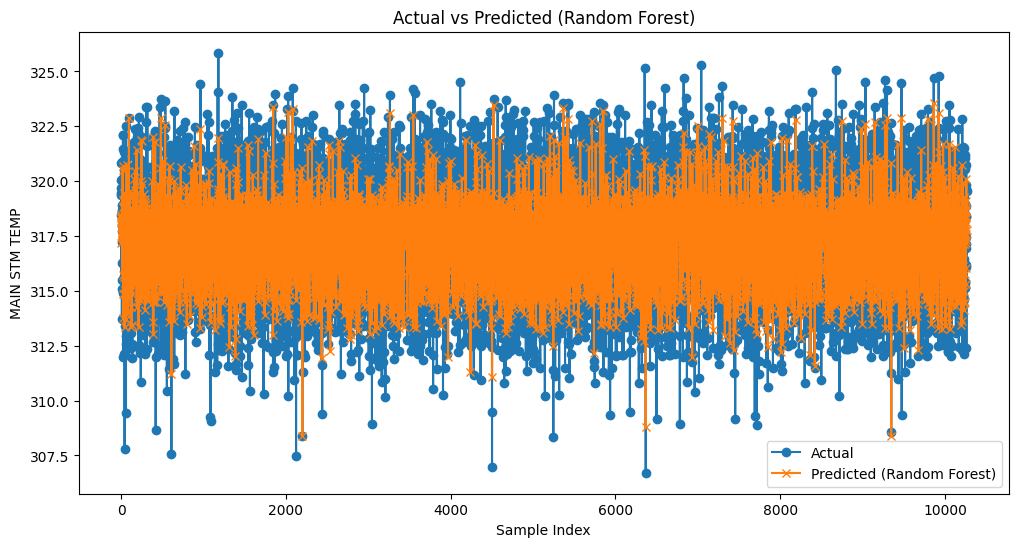

In [18]:
# Visualisasi Prediksi vs Aktual (Random Forest)

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted (Random Forest)', marker='x')
plt.title('Actual vs Predicted (Random Forest)')
plt.xlabel('Sample Index')
plt.ylabel('MAIN STM TEMP')
plt.legend()
plt.show()

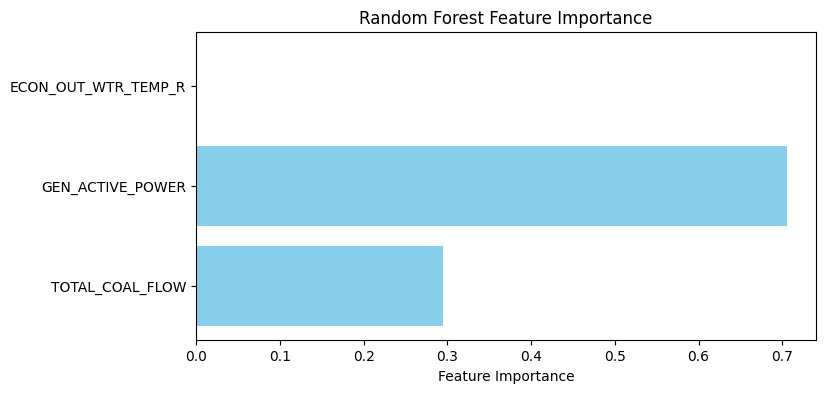

In [19]:
# Feature Importance Random Forest

importances = best_rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
plt.barh(features, importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

# Tuning Model Ridge Regression

In [20]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
params_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge = Ridge()
grid_ridge = GridSearchCV(estimator=ridge, param_grid=params_grid, cv=3, scoring='r2', verbose=1, n_jobs=-1)
grid_ridge.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


GridSearchCV(cv=3, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]}, scoring='r2',
             verbose=1)

In [21]:
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

In [22]:
print("\n--- Ridge Regression Tuning Results ---")
print("Best Ridge alpha:", grid_ridge.best_params_)
print("R² Score Ridge:", r2_score(y_test, y_pred_ridge))
print("RMSE Ridge:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


--- Ridge Regression Tuning Results ---
Best Ridge alpha: {'alpha': 10}
R² Score Ridge: 0.16323516028114726
RMSE Ridge: 2.249267654066678


# Tuning Model Decision Tree Regression

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
params_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
dt = DecisionTreeRegressor(random_state=42)
grid_dt = GridSearchCV(estimator=dt, param_grid=params_grid, cv=3, scoring='r2', verbose=1, n_jobs=-1)
grid_dt.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5]},
             scoring='r2', verbose=1)

In [24]:
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

In [25]:
print("\n--- Decision Tree Tuning Results ---")
print("Best Decision Tree params:", grid_dt.best_params_)
print("R² Score Decision Tree:", r2_score(y_test, y_pred_dt))
print("RMSE Decision Tree:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))


--- Decision Tree Tuning Results ---
Best Decision Tree params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
R² Score Decision Tree: 0.2749631811345271
RMSE Decision Tree: 2.093724123970656


# Tuning Model Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the parameter grid
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [27]:
r2 = r2_score(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))

In [28]:
print("\n--- Linear Regression Results ---")
print("Coefficients:", r2)
print("Intercept:", rmse)


--- Linear Regression Results ---
Coefficients: 0.16322996106740895
Intercept: 2.2492746419350538


In [44]:
import joblib

joblib.dump(best_rf, 'best_rf_model.pkl')

model = joblib.load('best_rf_model.pkl')

In [45]:
joblib.dump(linear_model, 'linear_model.pkl')
joblib.dump(best_ridge, 'ridge_model.pkl')
joblib.dump(best_dt, 'decision_tree_model.pkl')
joblib.dump(best_rf, 'random_forest_model.pkl')

['random_forest_model.pkl']